# Importation

In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pyoperators import (
    MPI,
    BlockDiagonalOperator,
    BlockRowOperator,
    DenseOperator,
    DiagonalOperator,
    IdentityOperator,
    PackOperator,
    ReshapeOperator,
)
from pyoperators.iterative.core import AbnormalStopIteration
from pysimulators.interfaces.healpy import (
    Spherical2HealpixOperator,
)
from pysimulators.interfaces.healpy.operators import HealpixConvolutionGaussianOperator
from scipy.optimize import minimize

from qubic.lib.Instrument.Qacquisition import QubicInstrumentType
from qubic.lib.Instrument.Qinstrument import compute_freq
from qubic.lib.Instrument.Qnoise import QubicTotNoise
from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import CMBModel
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps, WindPerturbation
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing
from qubic.lib.Qscene import QubicScene

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

In [2]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict
qubic_dict["instrument_type"] = "UWB"
qubic_dict["interp_projection"] = False

npix = hp.nside2npix(params["nside"])
npointings = params["npointings"]

# Scanning Strategy

## Galactic Coordinates

In [4]:
### Random pointing
qubic_dict["random_pointing"] = True
qubic_dict["date_obs"] = "2023-10-01 22:57:00.000"
qubic_dict["period"] = 3
qubic_dict["fix_azimuth"]["apply"] = False

### Sweepingpointing
if params["sweeping_pointings"]:
    qubic_dict["random_pointing"] = False
    qubic_dict["sweeping_pointing"] = True

    qubic_dict['angspeed'] = 0.1
    qubic_dict['delta_az'] = 20
    qubic_dict['nsweeps_per_elevation'] = 1
    qubic_dict['duration'] = 10
    # npointings = 3600 * qubic_dict['duration'] / qubic_dict['period']
    qubic_dict["period"] = 3600 * qubic_dict["duration"] / npointings

### Repeat pointing
# qubic_dict["repeat_pointing"] = False

print("Sampling period : ", qubic_dict["period"], " (s)")
print("Duration : ", qubic_dict["duration"], " (h)")

### Build scanning strategy instance
q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array(
    [np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)]
)

Sampling period :  7.2  (s)
Duration :  10  (h)


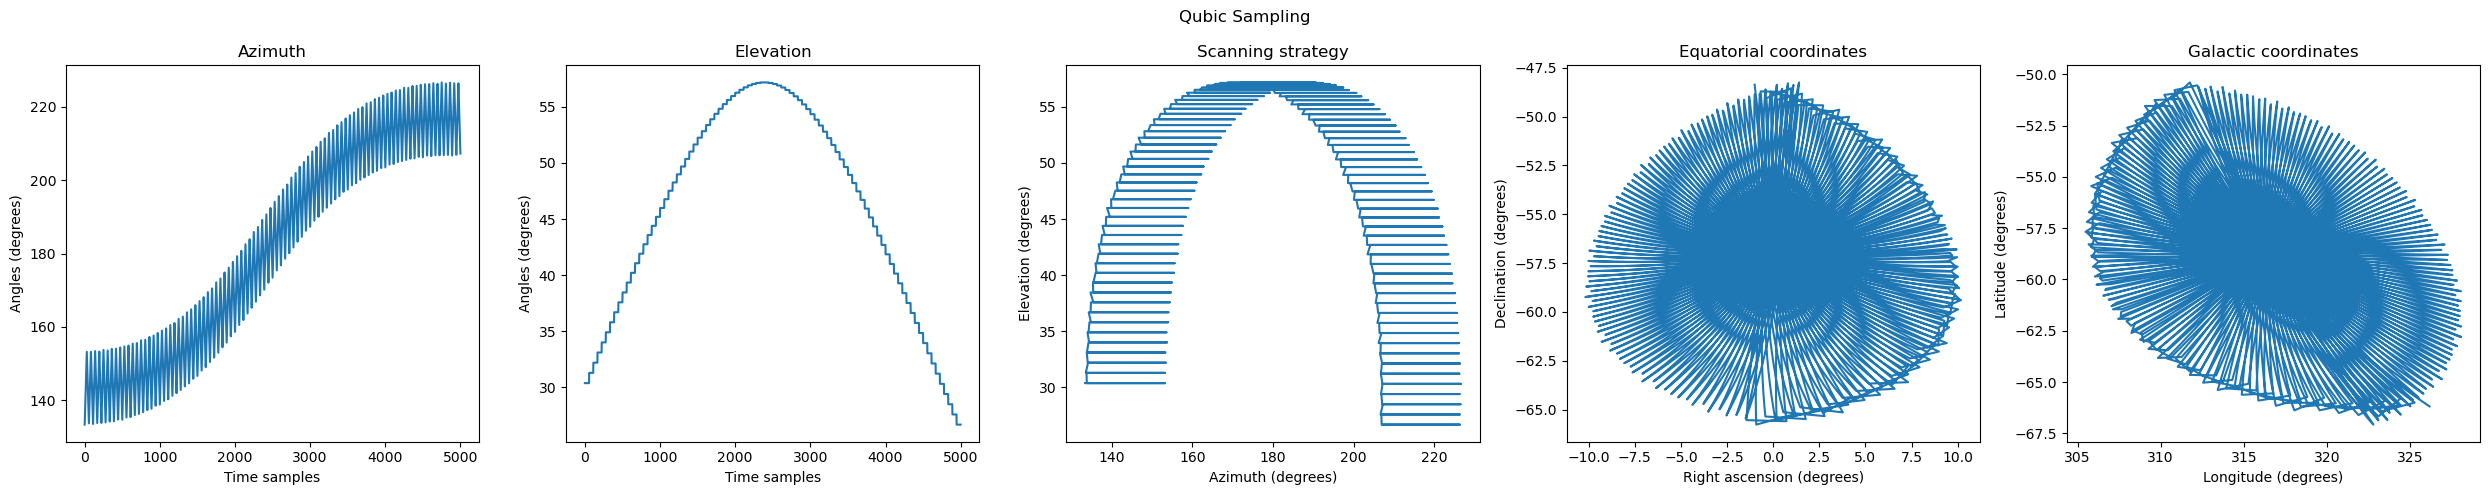

In [5]:
### Plot scanning strategy
az, el = q_sampling_gal.azimuth, q_sampling_gal.elevation

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Azimuth plot
axs[0].plot(az)
axs[0].set_title("Azimuth")
axs[0].set_xlabel("Time samples")
axs[0].set_ylabel("Angles (degrees)")

# Elevation plot
axs[1].plot(el)
axs[1].set_title("Elevation")
axs[1].set_xlabel("Time samples")
axs[1].set_ylabel("Angles (degrees)")

# Scanning strategy plot
axs[2].plot(az, el)
axs[2].set_title("Scanning strategy")
axs[2].set_xlabel("Azimuth (degrees)")
axs[2].set_ylabel("Elevation (degrees)")

# Equatorial coordinates plot
axs[3].plot(
    (q_sampling_gal.equatorial[:, 0] + 180) % 360 - 180, q_sampling_gal.equatorial[:, 1]
)
axs[3].set_title("Equatorial coordinates")
axs[3].set_xlabel("Right ascension (degrees)")
axs[3].set_ylabel("Declination (degrees)")

# Galactic coordinates plot
axs[4].plot(q_sampling_gal.galactic[:, 0], q_sampling_gal.galactic[:, 1])
axs[4].set_title("Galactic coordinates")
axs[4].set_xlabel("Longitude (degrees)")
axs[4].set_ylabel("Latitude (degrees)")

fig.suptitle("Qubic Sampling")
plt.tight_layout()
plt.show()

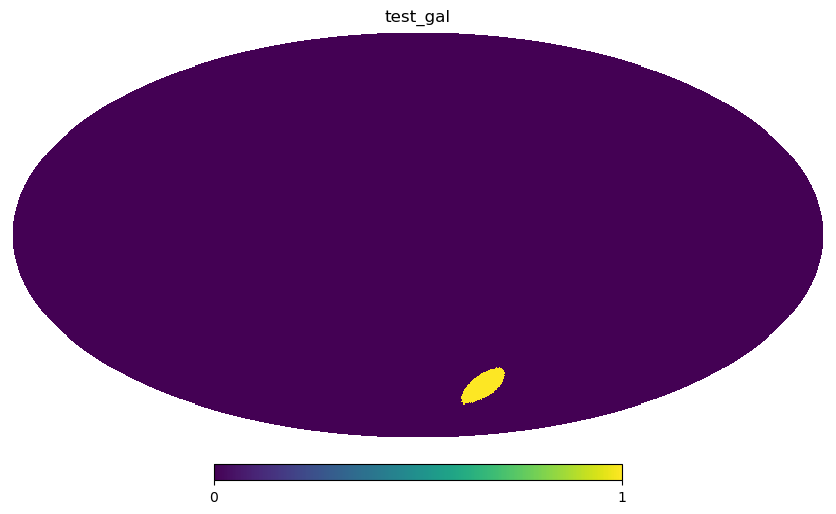

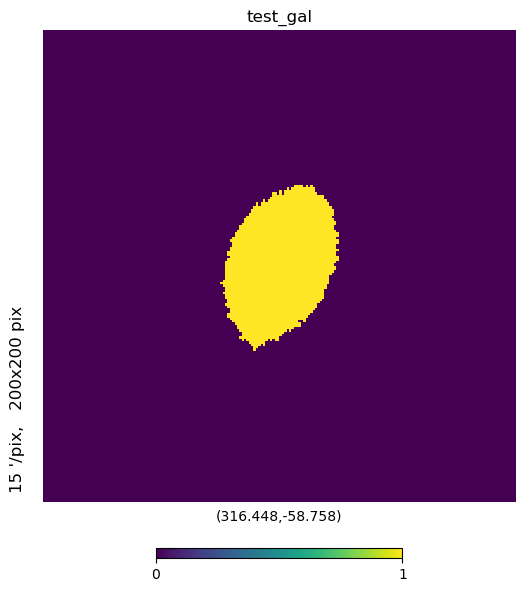

In [6]:
### Test scanning strategy plots
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(q_sampling_gal.galactic)
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(test_gal, title="test_gal", cmap="viridis", reso=15, rot=center_gal)

## Wind

We are adding wind by shifting the scanning strategy. It is roughly equivalent than shifting atm pixels
in the map, but slighlty less expensive in terms of computational ressources. 

## Local Coordinates

In [7]:
### Define scanning strategy for atm observation
if params["wind"]:
    wind_class = WindPerturbation(params, q_sampling_gal)
    q_sampling_local = wind_class.get_deviated_qubic_sampling()
else:
    q_sampling_local = QubicSampling(
        q_sampling_gal.index.size,
        date_obs=qubic_dict["date_obs"],
        period=qubic_dict["period"],
        latitude=qubic_dict["latitude"],
        longitude=qubic_dict["longitude"],
    )

    q_sampling_local.azimuth = q_sampling_gal.azimuth
    q_sampling_local.elevation = q_sampling_gal.elevation
    q_sampling_local.pitch = q_sampling_gal.pitch
    q_sampling_local.angle_hwp = q_sampling_gal.angle_hwp

    q_sampling_local.fix_az = True

181.6503225629004 45.87202937827066


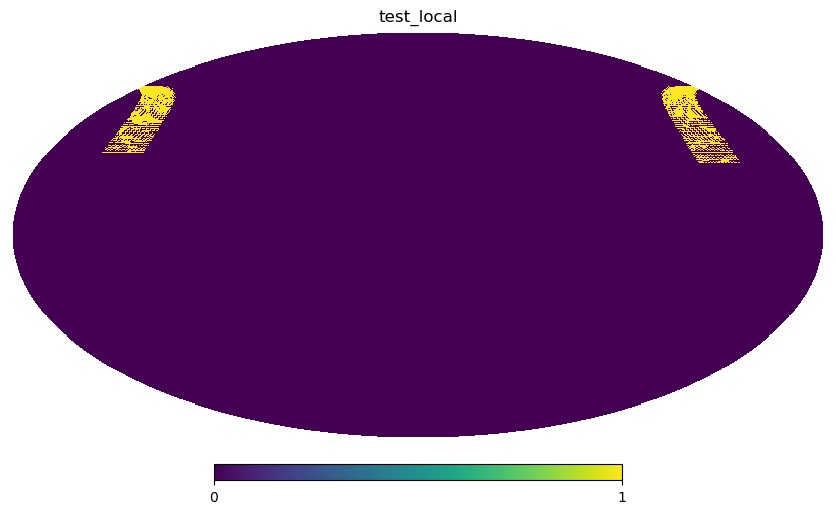

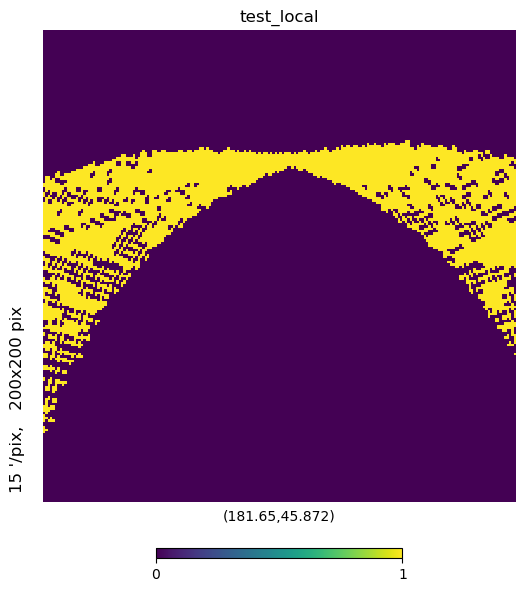

In [8]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_local", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_local",
    cmap="viridis",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)

print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

# Input Maps

## CMB

(8, 196608, 3)


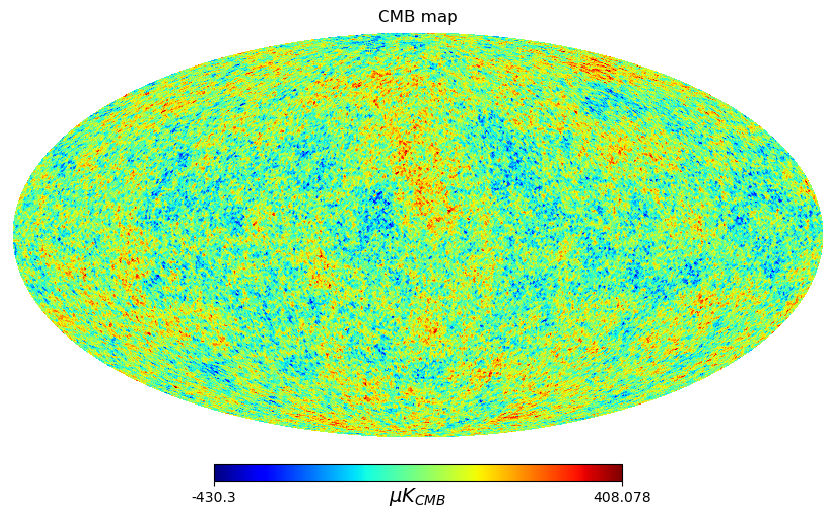

In [9]:
# Build CMB map
cl_cmb = CMBModel(None).give_cl_cmb(r=0, Alens=1)
cmb_map = hp.synfast(cl_cmb, params["nside"], new=True, verbose=False).T

cmb_maps = np.ones((params["nsub_in"], hp.nside2npix(params["nside"]), 3))
cmb_maps *= cmb_map[None]
print(cmb_maps.shape)

hp.mollview(cmb_map[:, 0], cmap="jet", title="CMB map", unit=r"$µK_{CMB}$")

## Atmosphere

In [10]:
atm_maps = np.zeros((cmb_maps.shape))
atm_maps[..., 0] = atm.get_temp_maps(atm.delta_rho_map) / 1e3
print(atm_maps.shape)

(8, 196608, 3)


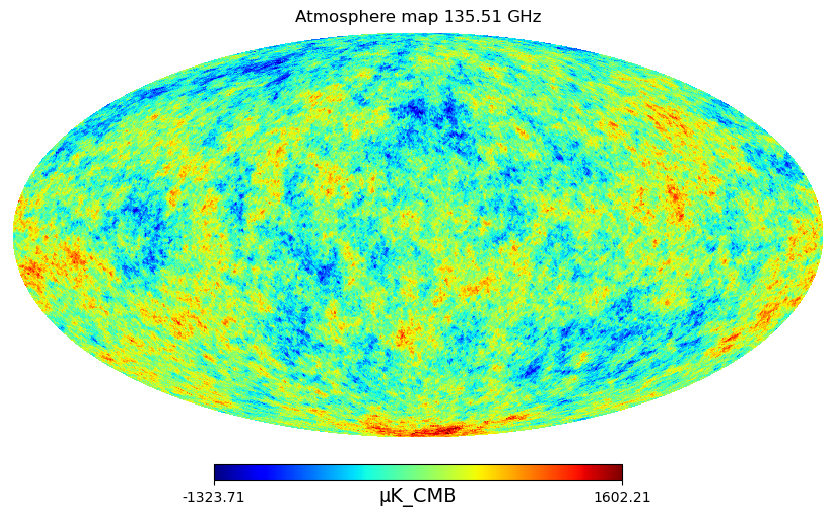

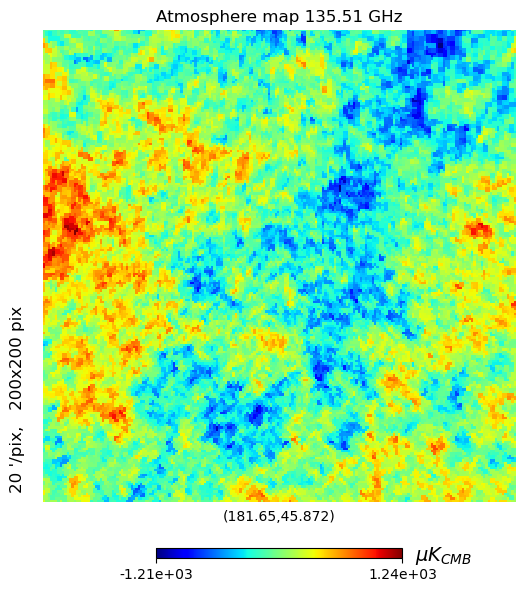

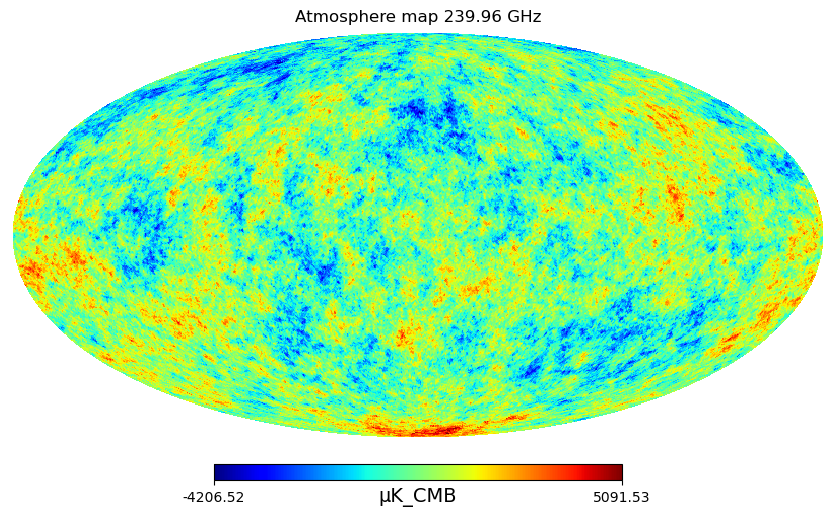

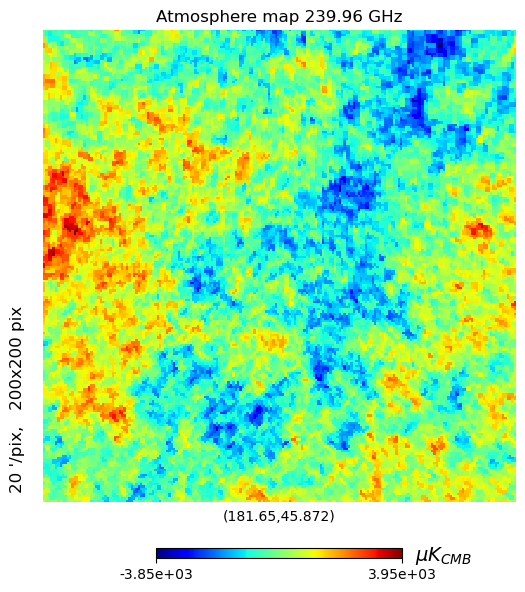

In [11]:
index_nu = 0
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

index_nu = -1
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

## Apply convolutions - Input Maps

In [12]:
if params["convolutions"]:
    fwhm_synthbeam150 = 0.006853589624526168

    _, _, filter_nus150, deltas150, _, _ = compute_freq(
        150,
        int(params["nsub_in"] / 2),
        relative_bandwidth=qubic_dict["filter_relative_bandwidth"],
        frequency_spacing="log",
    )
    _, _, filter_nus220, deltas220, _, _ = compute_freq(
        220,
        int(params["nsub_in"] / 2),
        relative_bandwidth=qubic_dict["filter_relative_bandwidth"],
        frequency_spacing="log",
    )

    nus_tod = np.concatenate((filter_nus150, filter_nus220)) * 1e9
    fwhm_tod = fwhm_synthbeam150 * 150e9 / nus_tod
    print("Frequencies : ", nus_tod)
    print("FWHM : ", fwhm_tod)

    for isub in range(nus_tod.size):
        C = HealpixConvolutionGaussianOperator(fwhm=fwhm_tod[isub])
        atm_maps[isub] = C(atm_maps[isub])
        cmb_maps[isub] = C(cmb_maps[isub])

## Input Maps

In [13]:
maps = []

if params.get("cmb", False):
    maps.append(cmb_maps)

if params.get("atm", False):
    maps.append(atm_maps)

if maps:
    input_maps = np.concatenate(maps, axis=0)
else:
    input_maps = np.zeros((npix, 3))

print(input_maps.shape)

(16, 196608, 3)


## True maps

In [14]:
### Build Expected Atm Maps
true_maps = []

# Build the reconstructed maps and frequency by taking the mean inside each reconstructed frequency band
if params["cmb"]:
    true_maps.append(cmb_map)
if params["atm"]:
    true_maps.append(np.mean(atm_maps, axis=0))
true_maps = np.array(true_maps)
if true_maps.shape[0]==1:
    true_maps = true_maps[0]
print(true_maps.shape)

if params["convolutions"]:
    C = HealpixConvolutionGaussianOperator(fwhm=np.mean(fwhm_tod))
    for i in range(true_maps.shape[0]):
        true_maps[i] = C(true_maps[i])

min_input = np.min(true_maps, axis=1)
max_input = np.max(true_maps, axis=1)

max = np.max([min_input, max_input], axis=0)
min_input = -max
max_input = max

(2, 196608, 3)


# Mixing Matrix

(8, 2)


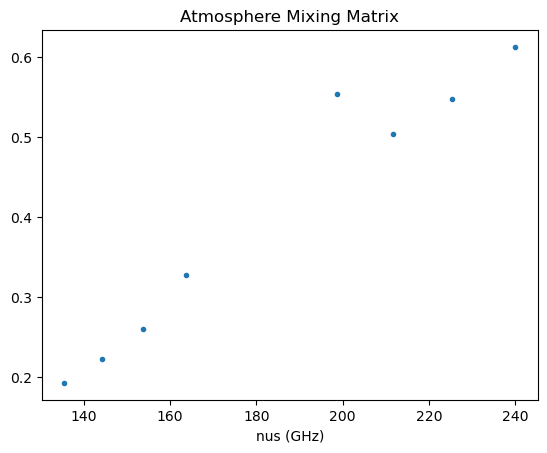

In [15]:
mixing_matrix = np.ones((params["nsub_in"], 2))
# Atm mixing matrix
mixing_matrix[:, 1] = (
    atm.temperature * atm.integrated_abs_spectrum * atm.mean_water_vapor_density
)
print(mixing_matrix.shape)

plt.plot(atm.frequencies, mixing_matrix[:, 1], ".")
plt.xlabel("nus (GHz)")
plt.title("Atmosphere Mixing Matrix")
plt.show()

# Build QUBIC Instances

In [16]:
q_acquisition_local = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_local
)

q_acquisition_gal = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_gal
)

qubic_scene = QubicScene(qubic_dict)
qubic_noise = QubicTotNoise(qubic_dict, q_sampling_gal, qubic_scene)

Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (4960000,9) elements = 681.15234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Alloca

In [17]:
coverage_gal = q_acquisition_gal.coverage
covnorm_gal = coverage_gal / coverage_gal.max()
seenpix_gal = covnorm_gal > params["coverage_cut"]
seenpix_gal_wo_cut = covnorm_gal > 0

coverage_local = q_acquisition_local.coverage
covnorm_local = coverage_local / coverage_local.max()
seenpix_local = covnorm_local > params["coverage_cut"]
seenpix_local_wo_cut = covnorm_local > 0

seenpix = []
if params["cmb"]:
    seenpix.append(seenpix_gal)
if params["atm"] :
    seenpix.append(seenpix_local)
seenpix = np.array(seenpix)
if seenpix.shape[0] == 1:
    seenpix = seenpix[0]

# Build QUBIC Operaotors

In [18]:
# Galactic Coordinates

H_gal = q_acquisition_gal.get_operator()
print("H_gal :", H_gal.shapein, H_gal.shapeout)
invN_gal = q_acquisition_gal.get_invntt_operator(1, 1, 1)
print("invN_gal :", invN_gal.shapein, invN_gal.shapeout)

H_gal : (8, 196608, 3) (4960000,)
invN_gal : (992, 5000) (992, 5000)


In [19]:
# Local Coordinates

H_local = q_acquisition_local.get_operator()

invN_local = q_acquisition_local.get_invntt_operator(1, 1, 1)

In [20]:
### Full MM
R = ReshapeOperator((2 * 992, npointings), (npointings * 992 * 2))

r = ReshapeOperator((npix, 3), (1, npix, 3))
A_gal = (
    DenseOperator(
        mixing_matrix[:, 0, None],
        broadcast="rightward",
        shapein=(1, npix, 3),
        shapeout=(params["nsub_in"], npix, 3),
    )
    * r
)
A_local = (
    DenseOperator(
        mixing_matrix[:, 1, None],
        broadcast="rightward",
        shapein=(1, npix, 3),
        shapeout=(params["nsub_in"], npix, 3),
    )
    * r
)

def build_H(H_gal, H_local, A_gal, A_local):

    H_list = []
    if params["cmb"] :
        H_list.append(H_gal(A_gal))
    if params["atm"] :
        H_list.append(H_local(A_local))
        
    shape = len(H_list)
    print(shape)
    print(H_list[0].shapein, H_list[0].shapeout)
    if shape==1:
        return BlockRowOperator(H_list, axisin=0)
    else:
        return BlockRowOperator(H_list, axisin=0) * ReshapeOperator(
        (shape, npix, 3), (shape * npix, 3)
    )
    
H = build_H(H_gal, H_local, A_gal, A_local)

R = ReshapeOperator(invN_gal.shapein, H.shapeout)
invN = R(invN_gal(R.T))

tod = H(true_maps) + qubic_noise.total_noise(1, 1, 1, seed_noise=params["seed"]).ravel()
print(tod.shape)

2
(196608, 3) (4960000,)
Duration at 150 GHz is 3 yrs
Duration at 220 GHz is 3 yrs
(4960000,)


# TOD filtering

## TOD Library

Ndet :  992 | Npointing :  5000
Ndet x Npointings :  4960000
TOD shape :  (4960000,)


Text(0, 0.5, 'TOD')

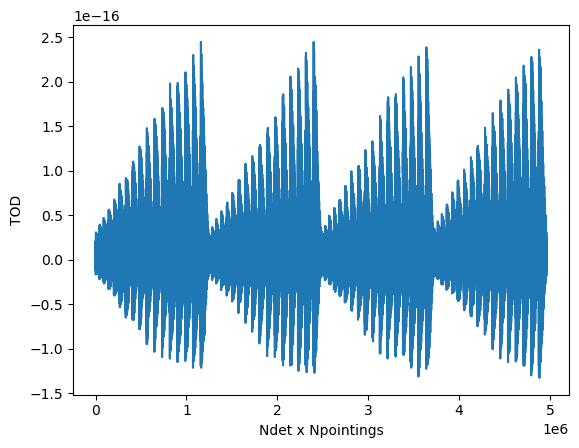

In [21]:
plt.figure()
print("Ndet : ", 992, "| Npointing : ", npointings)
print("Ndet x Npointings : ", 992 * npointings)
print("TOD shape : ", tod.shape)
plt.plot(tod)
plt.xlabel("Ndet x Npointings")
plt.ylabel("TOD")

Text(0, 0.5, 'TOD')

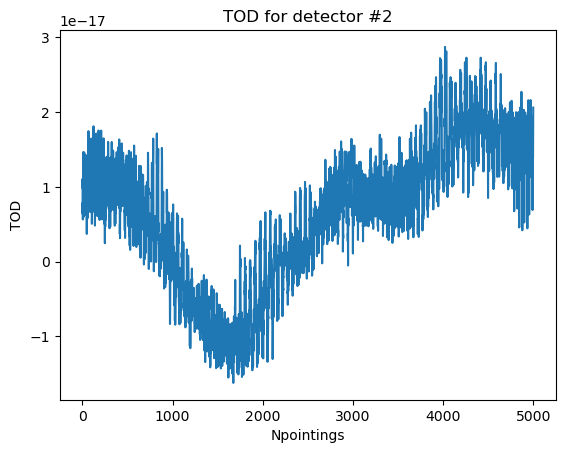

In [22]:
def tod_per_det(tod, idet, npointings):
    return tod[idet*npointings : (idet + 1)*npointings]

idet = 2
tod_det = tod_per_det(tod, idet, npointings)
plt.figure()
plt.plot(tod_det)
plt.title(f"TOD for detector #{idet}")
plt.xlabel("Npointings")
plt.ylabel("TOD")

## TOD Power Spectrum

In [23]:
def compute_ps(tod, fs=qubic_dict["period"]):
    N = tod.shape[0]
    freq = np.fft.rfftfreq(N, d=1/fs)
    
    ps = (1/(fs*N) * np.abs(np.fft.rfft(tod))**2)
    
    # One sided correction
    ps[1:-1] *= 2
    
    return freq, ps

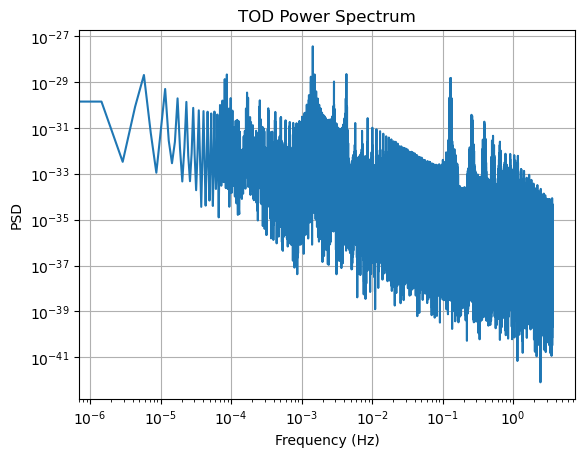

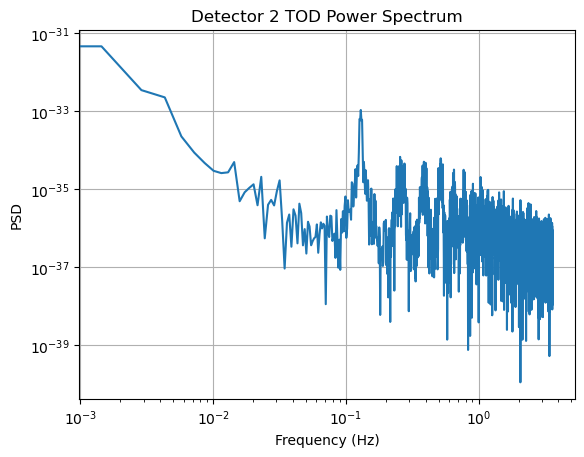

In [24]:
freq, ps = compute_ps(tod)
freq_det, ps_det = compute_ps(tod_det)

plt.figure()
plt.title("TOD Power Spectrum")
plt.plot(freq, ps)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.grid(True)
plt.xscale("log")
plt.yscale("log")

plt.figure()
plt.title(f"Detector {idet} TOD Power Spectrum")
plt.plot(freq_det, ps_det)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.grid(True)
plt.xscale("log")
plt.yscale("log")

## Filtering

In [25]:
def highpass_filter(tod, fs, fc):

    N = len(tod)
    fft = np.fft.rfft(tod - np.mean(tod))
    freqs = np.fft.rfftfreq(N, d=1/fs)

    fft[freqs < fc] = 0
    return np.fft.irfft(fft, n=N)

def prewhiten(tod, fs, fk=0.1, alpha=1.0, white_level=1.0):

    N = len(tod)
    fft = np.fft.rfft(tod - np.mean(tod))
    freqs = np.fft.rfftfreq(N, d=1/fs)

    P_f = white_level * (1 + (fk / np.maximum(freqs, 1e-10))**alpha)

    fft_whitened = fft / np.sqrt(P_f)
    return np.fft.irfft(fft_whitened, n=N)

In [26]:
# Need to fit fcut, fknee and alpha ! 

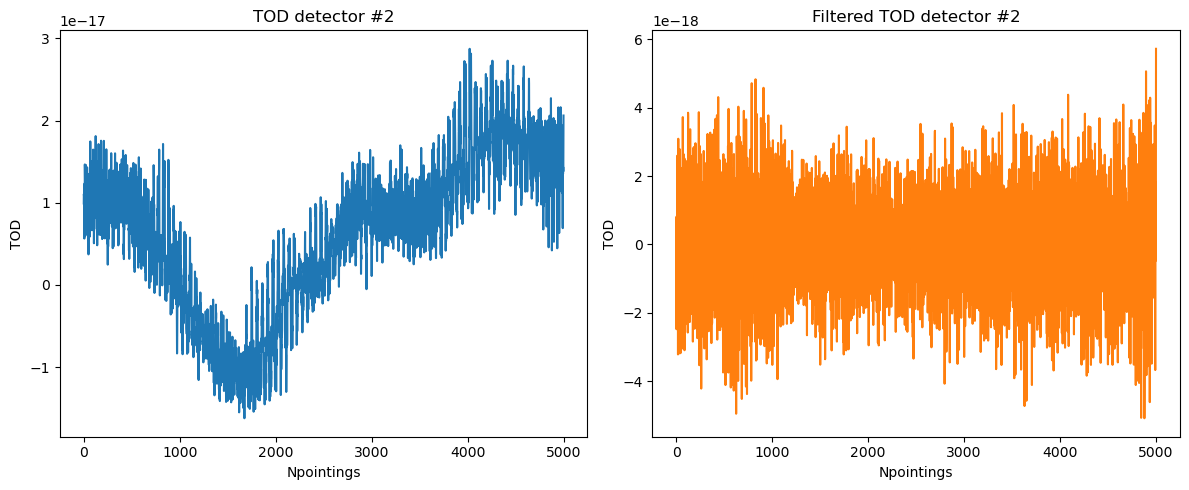

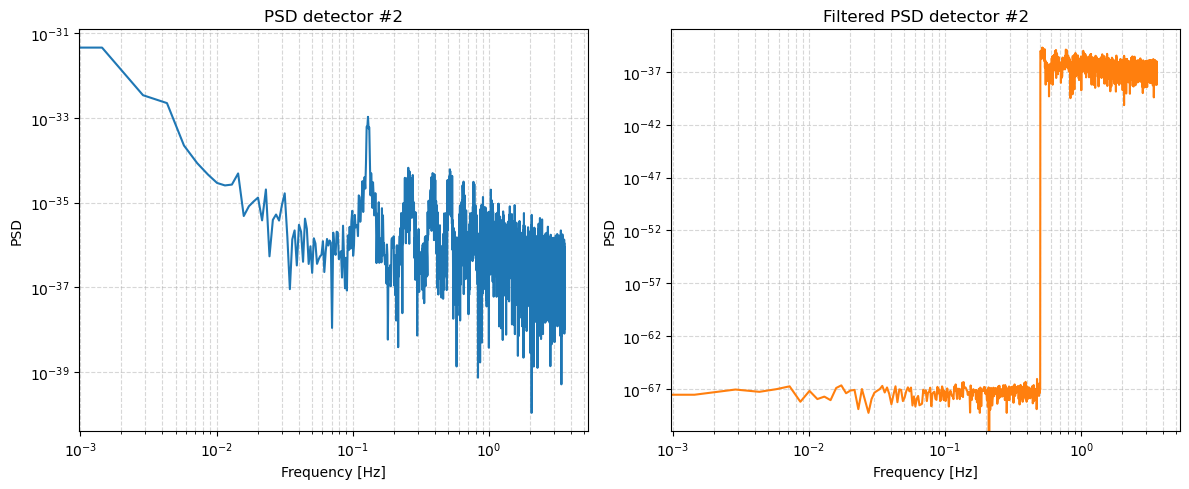

In [27]:
### Test 
fs = qubic_dict["period"]
fcut = 0.5
fknee = 1
alpha = 1

idet = 2
tod_det = tod_per_det(tod, idet, npointings)
tod_det_w = prewhiten(tod_det, fs, fk=fknee, alpha=alpha)
tod_det_filtered = highpass_filter(tod_det_w, fs, fc=fcut)

# TOD
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tod_det, color="tab:blue")
plt.title(f"TOD detector #{idet}")
plt.xlabel("Npointings")
plt.ylabel("TOD")

plt.subplot(1, 2, 2)
plt.plot(tod_det_filtered, color="tab:orange")
plt.title(f"Filtered TOD detector #{idet}")
plt.xlabel("Npointings")
plt.ylabel("TOD")

plt.tight_layout()
plt.show()

# Power Spectrum
freq_det, ps_det = compute_ps(tod_det)
freq_det_filtered, ps_det_filtered = compute_ps(tod_det_filtered, fs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.loglog(freq_det, ps_det, color="tab:blue")
plt.title(f"PSD detector #{idet}")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.subplot(1, 2, 2)
plt.loglog(freq_det_filtered, ps_det_filtered, color="tab:orange")
plt.title(f"Filtered PSD detector #{idet}")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

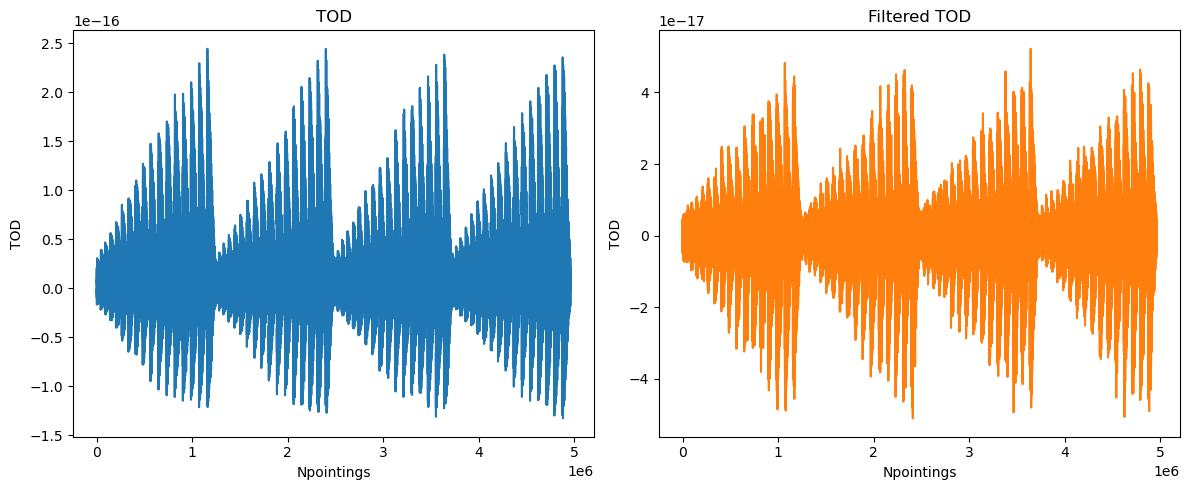

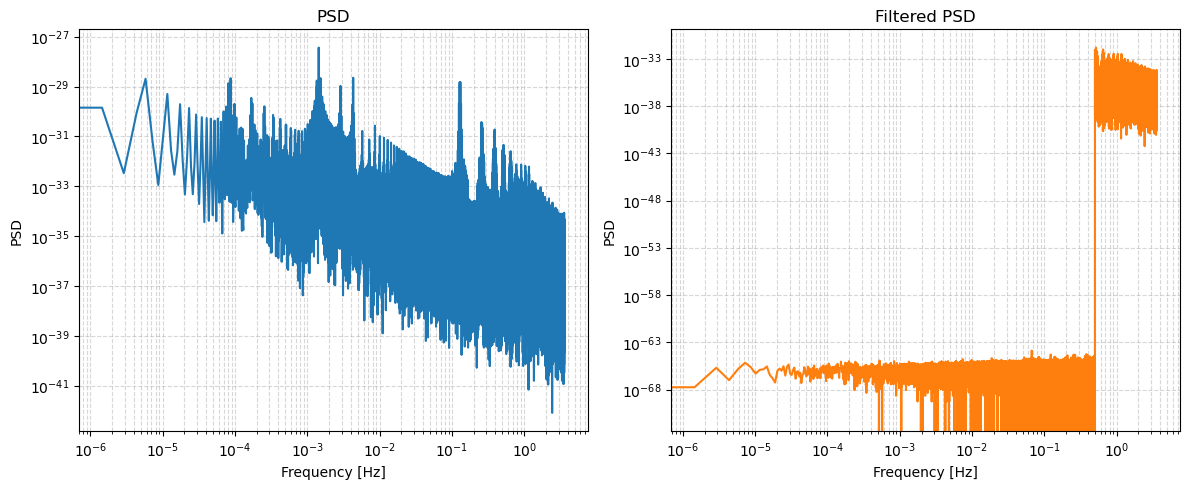

In [28]:
### Test Full
fs = qubic_dict["period"]
tod_w = prewhiten(tod, fs, fk=fknee, alpha=alpha)
tod_filtered = highpass_filter(tod_w, fs, fc=fcut)

# TOD
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tod, color="tab:blue")
plt.title(f"TOD")
plt.xlabel("Npointings")
plt.ylabel("TOD")

plt.subplot(1, 2, 2)
plt.plot(tod_filtered, color="tab:orange")
plt.title(f"Filtered TOD")
plt.xlabel("Npointings")
plt.ylabel("TOD")

plt.tight_layout()
plt.show()

# Power Spectrum
freq, ps = compute_ps(tod)
freq_filtered, ps_filtered = compute_ps(tod_filtered, fs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.loglog(freq, ps, color="tab:blue")
plt.title(f"PSD")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.subplot(1, 2, 2)
plt.loglog(freq_filtered, ps_filtered, color="tab:orange")
plt.title(f"Filtered PSD")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Map-Making